In [2]:
import pyvo
from astropy.table import Table
import re
import matplotlib.pyplot as plt
import numpy as np

In [3]:
nasa = pyvo.dal.TAPService("https://exoplanetarchive.ipac.caltech.edu/TAP")


In [4]:
# columns_query = nasa.search("""SELECT top 1 FROM pscomppars""")

In [5]:
# ts = nasa.tables

In [6]:
# print(list(i for i in ts.keys()))


In [7]:
columns_query = nasa.search("SELECT column_name FROM TAP_SCHEMA.columns WHERE table_name = 'pscomppars'")

In [8]:
psc_columns = columns_query["column_name"].data

In [9]:
pattern = re.compile(".*ref.*")

ref_columns = [c for c in psc_columns if pattern.match(c)]
ref_columns

['sy_pm_reflink',
 'sy_plx_reflink',
 'sy_dist_reflink',
 'sy_bmag_reflink',
 'sy_vmag_reflink',
 'sy_jmag_reflink',
 'sy_hmag_reflink',
 'sy_kmag_reflink',
 'sy_umag_reflink',
 'sy_rmag_reflink',
 'sy_imag_reflink',
 'sy_zmag_reflink',
 'sy_w1mag_reflink',
 'sy_w2mag_reflink',
 'sy_w3mag_reflink',
 'sy_w4mag_reflink',
 'sy_gmag_reflink',
 'sy_gaiamag_reflink',
 'sy_tmag_reflink',
 'pl_orbtper_systemref',
 'pl_tranmid_systemref',
 'sy_kepmag_reflink',
 'st_spectype_reflink',
 'st_rotp_reflink',
 'pl_projobliq_reflink',
 'pl_trueobliq_reflink',
 'pl_orbper_reflink',
 'ra_reflink',
 'pl_orblper_reflink',
 'pl_orbsmax_reflink',
 'pl_orbincl_reflink',
 'pl_orbtper_reflink',
 'pl_orbeccen_reflink',
 'pl_eqt_reflink',
 'pl_occdep_reflink',
 'pl_insol_reflink',
 'pl_dens_reflink',
 'pl_trandep_reflink',
 'pl_angsep_reflink',
 'pl_tranmid_reflink',
 'pl_trandur_reflink',
 'pl_rvamp_reflink',
 'pl_radj_reflink',
 'pl_rade_reflink',
 'pl_ratror_reflink',
 'pl_ratdor_reflink',
 'pl_imppar_reflink

In [10]:
len(ref_columns)

63

Trying to find out which columns contain calculated values

In [11]:
from concurrent.futures import ThreadPoolExecutor

def query_caltech(col):
    query = f"SELECT pl_name, {col} FROM pscomppars WHERE {col} LIKE '%Calculated Value%'"
    return nasa.search(query)

# Use ThreadPoolExecutor to run the synchronous searches concurrently
# Adjust max_workers based on the size of ref_columns to avoid hammering the server
with ThreadPoolExecutor() as executor:
    # executor.map preserves the order of your ref_columns
    calc_queries = list(executor.map(query_caltech, ref_columns))

# calc_queries = [
#     nasa.search(f"SELECT pl_name, {col} FROM pscomppars WHERE {col} = 'Calculated Value'")
#     for col in ref_columns
# ]

In [12]:
total_count = int(nasa.search("SELECT COUNT(*) FROM pscomppars")["count(*)"][0])

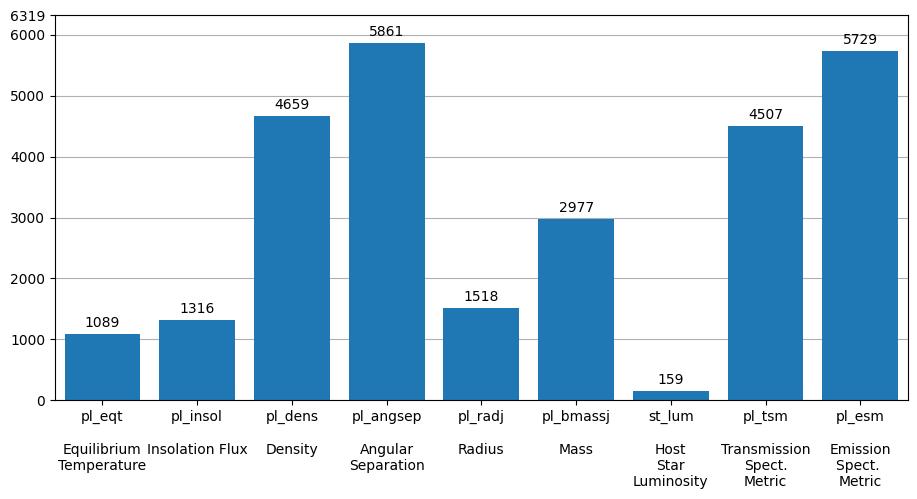

In [40]:
names = []
sub_names = {
    "pl_eqt": "Equilibrium\nTemperature",
    "pl_insol": "Insolation Flux",
    "pl_dens":"Density",
    "pl_angsep": "Angular\nSeparation", 
    "pl_radj": "Radius",
    "pl_bmassj":  "Mass",
    "st_lum": "Host\nStar\nLuminosity",
    "pl_tsm": "Transmission\nSpect.\nMetric",
    "pl_esm": "Emission\nSpect. \nMetric"
}
calcs = []
drop = ["pl_rade", "pl_bmasse"]

for q, name in zip(calc_queries, ref_columns):
    if len(q) > 0: 
        name = name.replace("_reflink", '')
        if name in drop:
            continue
        names.append(f"{name}\n\n{sub_names[name]}")
        calcs.append(len(q))

fig, ax = plt.subplots(figsize=(11,5))

_ = ax.bar_label(ax.bar(names, calcs), padding=3)
ax.set_axisbelow(True)
ax.grid(axis="y")
ax.set_ylim(0,total_count)
ax.set_xlim(-0.5,8.5)
ax.set_yticks([1000*i for i in range(round(total_count/1000)+1)] + [total_count])
plt.savefig("./plots/calculated_columns.pdf", bbox_inches="tight", dpi=300)

In [14]:
nasa.search("SELECT pl_name FROM pscomppars WHERE ")

DALQueryError: ORA-00936: missing expression

In [ ]:
example_calc_rad = nasa.search("SELECT * FROM pscomppars WHERE pl_name = '11 Com b'")

In [ ]:
example_calc_rad["pl_radj_reflink"].data[0]

'<a refstr=CALCULATED_VALUE href=/docs/pscp_calc.html target=_blank>Calculated Value</a>'